# FER-2013: Grad-CAM++ on the test set

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from pytorch_grad_cam import EigenCAM, GradCAM, GradCAMPlusPlus
from torchvision import transforms as T

from fer_2013.data.datamodule import build_transforms
from fer_2013.evaluation.evaluate import EMOTION_LABELS, load_checkpoint
from fer_2013.evaluation.gradcam import _ClassifierTarget, find_target_layer, overlay
from fer_2013.models.cnn import build_resnet18

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

model = build_resnet18(num_classes=len(EMOTION_LABELS), pretrained=False)
ckpt = load_checkpoint(Path("../checkpoints/best.pt"), model, map_location=DEVICE)
model.to(DEVICE).eval()
print(f"loaded checkpoint (epoch {ckpt['epoch']}, val macro_f1={ckpt['best_val_score']:.4f})")

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")
preds = np.load("../reports/test_preds.npy")
probs = np.load("../reports/test_probs.npy")
print(f"test: {X_test.shape}, preds: {preds.shape}")

device: cuda
loaded checkpoint (epoch 28, val macro_f1=0.6934)
test: (3589, 48, 48), preds: (3589,)


## CAM instances

One instance per method, created once and reused across all calls. Creating multiple `GradCAMPlusPlus` instances over the same model stacks hooks and breaks the backward pass.

In [2]:
TARGET_LAYER = find_target_layer(model)

cam_gradcam = GradCAM(model=model, target_layers=[TARGET_LAYER])
cam_gradcampp = GradCAMPlusPlus(model=model, target_layers=[TARGET_LAYER])
cam_eigen = EigenCAM(model=model, target_layers=[TARGET_LAYER])

print(
    "CAM instances ready:",
    type(cam_gradcam).__name__,
    type(cam_gradcampp).__name__,
    type(cam_eigen).__name__,
)

CAM instances ready: GradCAM GradCAMPlusPlus EigenCAM


## Helpers

Build a batch tensor for the model and render an image at target resolution for display.

In [3]:
VAL_TRANSFORM = build_transforms("val")
DISPLAY_RESIZE = T.Resize(
    (224, 224), interpolation=T.InterpolationMode.BICUBIC, antialias=True
)


def make_batch(indices: np.ndarray) -> torch.Tensor:
    """Build a (N, 3, 224, 224) float tensor from X_test indices."""
    imgs = []
    for idx in indices:
        x = X_test[idx]  # (48, 48) uint8
        t = torch.from_numpy(x).float().unsqueeze(0) / 255.0
        imgs.append(VAL_TRANSFORM(t))
    return torch.stack(imgs).to(DEVICE)


def show_image_at(idx: int) -> np.ndarray:
    """Render the test image at 224×224×3 uint8 for display."""
    x = X_test[idx]
    t = torch.from_numpy(x).float().unsqueeze(0) / 255.0
    resized = DISPLAY_RESIZE(t).repeat(3, 1, 1)
    img = resized.permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


def heatmaps_for(cam, images: torch.Tensor, class_indices: list[int]) -> np.ndarray:
    """Run a CAM instance on a batch, targeting the given class per sample."""
    targets = [_ClassifierTarget(c) for c in class_indices]
    result = cam(input_tensor=images.to(DEVICE), targets=targets)
    if result is None:
        raise RuntimeError("CAM returned None; check eval mode, device, targets.")
    return np.asarray(result, dtype=np.float32)

## Correctly classified

Grad-CAM++ on the logit of the predicted class (= true class here).

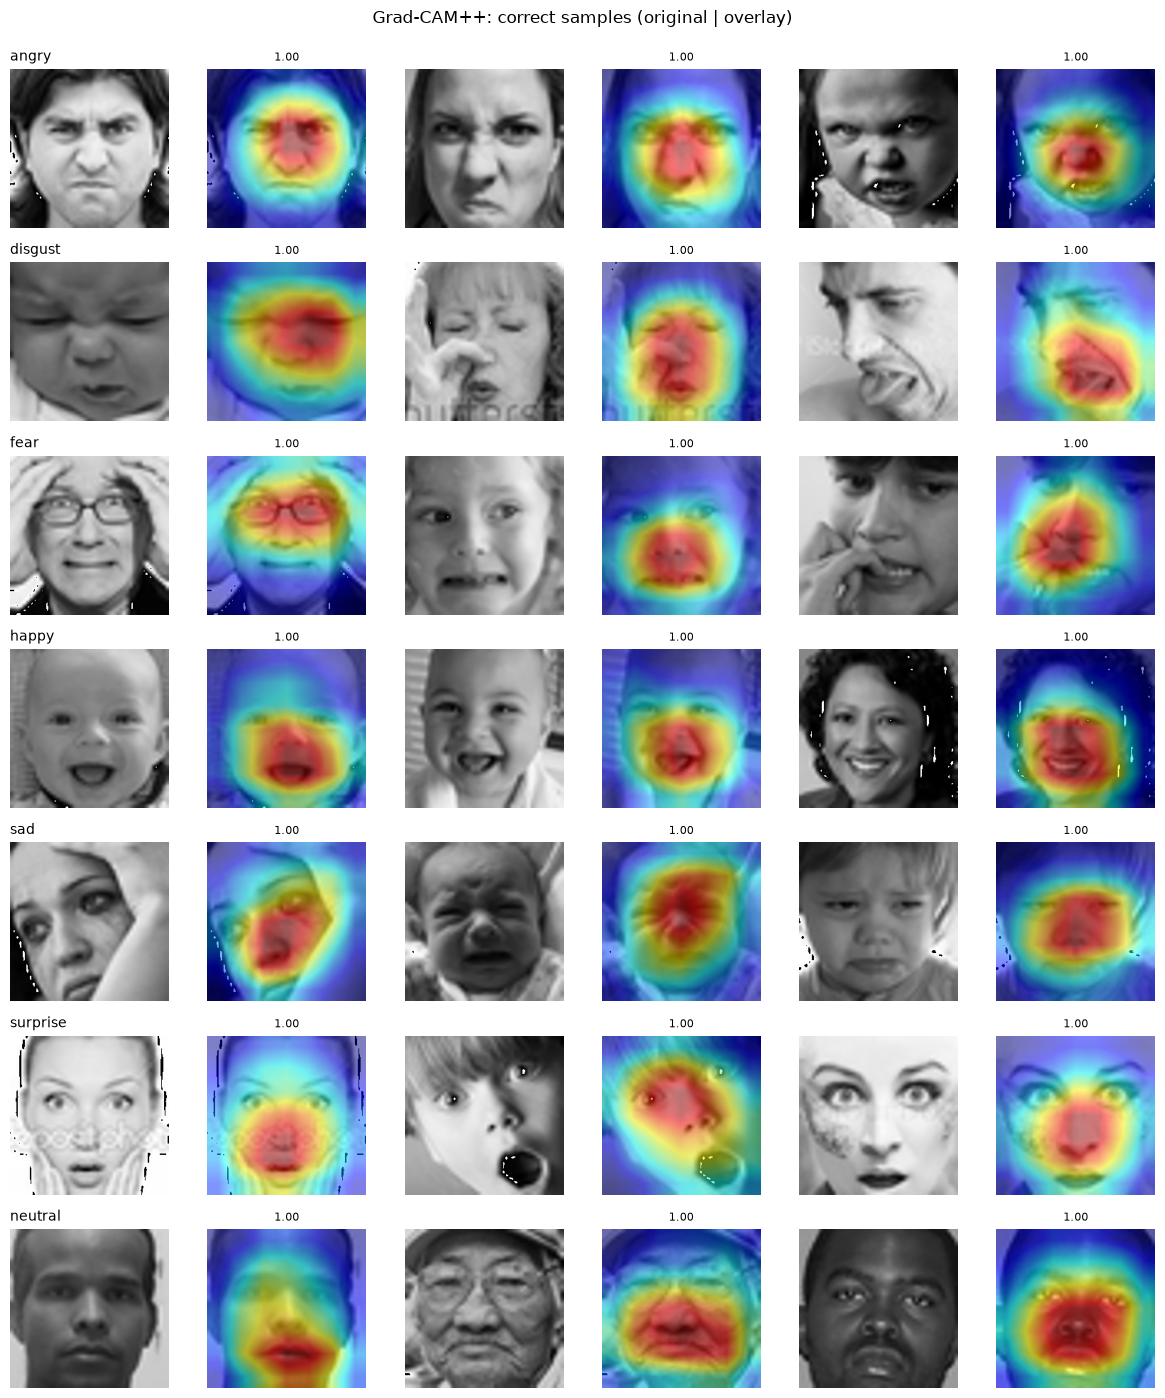

In [5]:
correct = preds == y_test
samples_per_class = 3
chosen: list[int] = []
for c in range(len(EMOTION_LABELS)):
    idxs = np.where(correct & (y_test == c))[0]
    confs = probs[idxs].max(axis=1)
    top = idxs[np.argsort(-confs)[:samples_per_class]]
    chosen.extend(top.tolist())

batch = make_batch(np.array(chosen))
class_indices = [int(y_test[i]) for i in chosen]
heatmaps = heatmaps_for(cam_gradcampp, batch, class_indices)

n_rows = len(EMOTION_LABELS)
n_cols = samples_per_class * 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
for row, label in enumerate(EMOTION_LABELS):
    for col in range(samples_per_class):
        i = row * samples_per_class + col
        idx = chosen[i]
        base = show_image_at(idx)
        cam_img = overlay(base, heatmaps[i], alpha=0.5)
        ax_img = axes[row, col * 2]
        ax_cam = axes[row, col * 2 + 1]
        ax_img.imshow(base)
        ax_img.axis("off")
        ax_cam.imshow(cam_img)
        ax_cam.axis("off")
        if col == 0:
            ax_img.set_title(label, loc="left", fontsize=10)
        ax_cam.set_title(f"{probs[idx].max():.2f}", fontsize=8)

plt.suptitle("Grad-CAM++: correct samples (original | overlay)", y=0.995)
plt.tight_layout()
plt.show()

## Confident misclassifications

Focus on the 8 wrong predictions with the highest confidence.

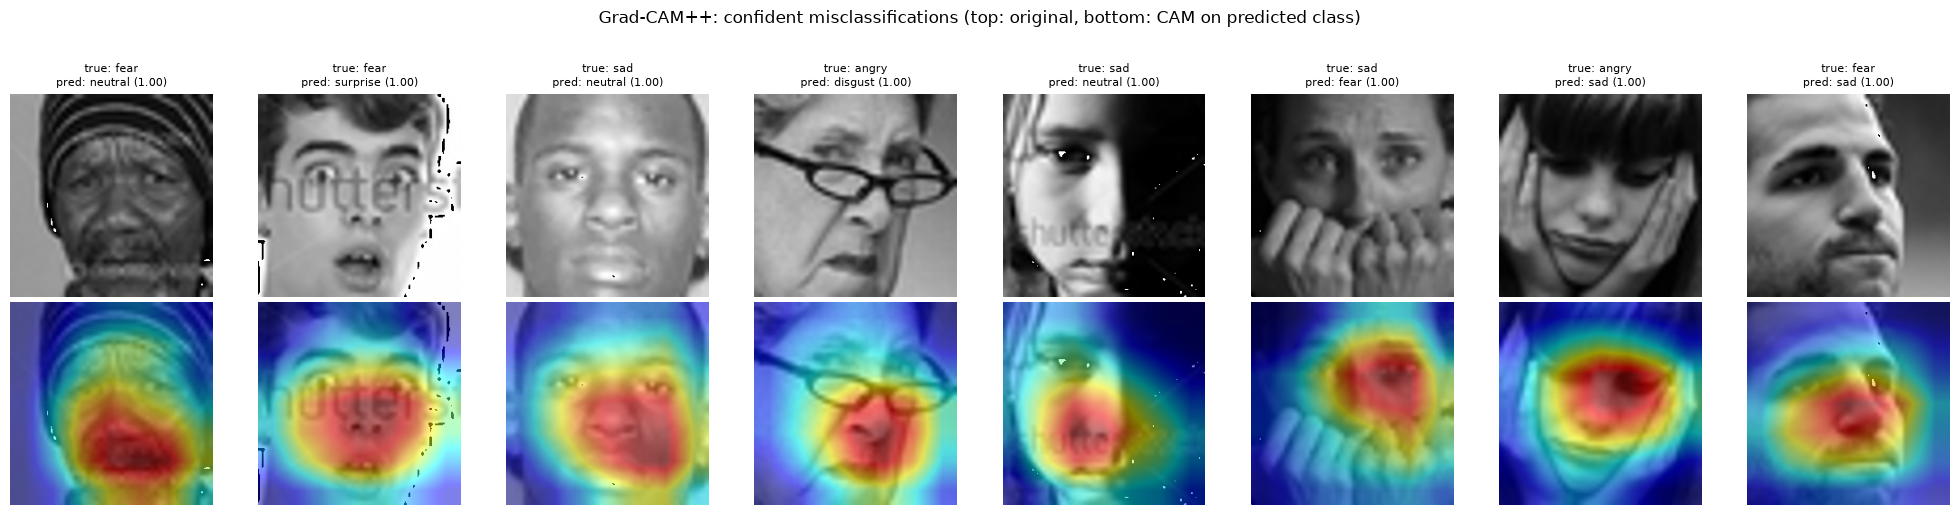

In [6]:
wrong = preds != y_test
wrong_idx = np.where(wrong)[0]
wrong_conf = probs[wrong_idx].max(axis=1)
worst = wrong_idx[np.argsort(-wrong_conf)[:8]]

batch = make_batch(worst)
cam_classes = [int(preds[i]) for i in worst]
heatmaps = heatmaps_for(cam_gradcampp, batch, cam_classes)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for col, (i, idx) in enumerate(zip(range(8), worst)):
    base = show_image_at(idx)
    cam_img = overlay(base, heatmaps[i], alpha=0.5)
    axes[0, col].imshow(base)
    axes[0, col].set_title(
        f"true: {EMOTION_LABELS[y_test[idx]]}\n"
        f"pred: {EMOTION_LABELS[preds[idx]]} ({probs[idx].max():.2f})",
        fontsize=8,
    )
    axes[0, col].axis("off")
    axes[1, col].imshow(cam_img)
    axes[1, col].axis("off")
plt.suptitle(
    "Grad-CAM++: confident misclassifications "
    "(top: original, bottom: CAM on predicted class)",
    y=1.02,
)
plt.tight_layout()
plt.show()

## Method comparison

GradCAM vs GradCAM++ vs EigenCAM on the same image. EigenCAM does not use a class target, so it shows the dominant activation regardless of class.

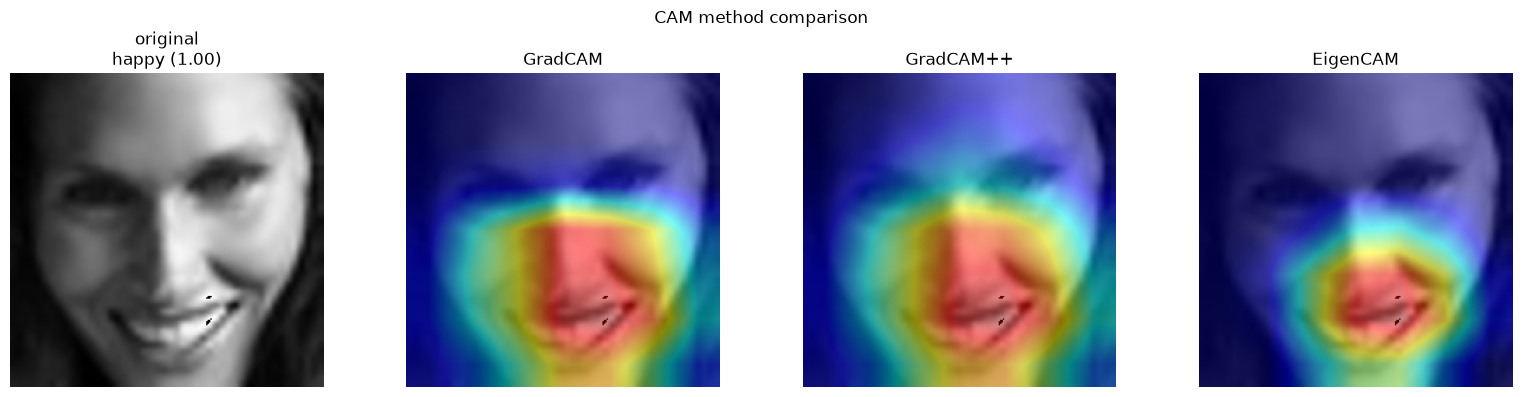

In [8]:
sample_idx = int(np.where(correct & (y_test == 3))[0][0])
batch = make_batch(np.array([sample_idx]))
class_idx = int(y_test[sample_idx])

hm_gradcam = heatmaps_for(cam_gradcam, batch, [class_idx])
hm_gradcampp = heatmaps_for(cam_gradcampp, batch, [class_idx])

eigen_result = cam_eigen(input_tensor=batch, targets=None)
hm_eigen = np.asarray(eigen_result, dtype=np.float32)

base = show_image_at(sample_idx)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(base)
axes[0].set_title(f"original\n{EMOTION_LABELS[class_idx]} ({probs[sample_idx].max():.2f})")
axes[0].axis("off")

axes[1].imshow(overlay(base, hm_gradcam[0], alpha=0.5))
axes[1].set_title("GradCAM")
axes[1].axis("off")

axes[2].imshow(overlay(base, hm_gradcampp[0], alpha=0.5))
axes[2].set_title("GradCAM++")
axes[2].axis("off")

axes[3].imshow(overlay(base, hm_eigen[0], alpha=0.5))
axes[3].set_title("EigenCAM")
axes[3].axis("off")

plt.suptitle("CAM method comparison")
plt.tight_layout()
plt.show()